# Quick Start Guide

EPIC-QEC is designed to facilitate the creation and benchmarking of Clifford computation using QEC solutions. It is divided into two subpackages: `core` and `modules`. The core contains the definitions of the abstractions as well as the compilation logic. The modules contain the implementations of the QEC solutions. To test a new QEC idea (code, surgery process, stabilizer schedule, etc.), one only has to focus on implementing the corresponding module, and then combine it with existing modules to test it in a full-stack, circuit-level noise experiment. Because the interfaces are well defined, it is easy to compare the performance of any new module with existing ones.

In this guide, we show how to use EPIC-QEC to design a logical CNOT on rotated surface codes using lattice surgery.

The first step is to define the stabilizer codes that are used. In general, EPIC-QEC supports any stabilizer code, and they are stored and processed as Tanner graphs. One can create any code given its symplectic parity-check matrix as well as a description of the logical operators. Here we use an existing macro to build `RotatedSurfaceCode` for a given distance. The system coordinates describe the positions of the patches; here they are required because lattice surgery relies on well-defined topology, but in general they are not required and may be used only for visualization purposes.

In [13]:
from epic import RotatedSurfaceCode

# Define stabilizer codes
code1 = RotatedSurfaceCode.from_distance(distance=3, system_coordinate=(0, 0))
code2 = RotatedSurfaceCode.from_distance(distance=3, system_coordinate=(0, 1))
code3 = RotatedSurfaceCode.from_distance(distance=3, system_coordinate=(1, 0))

The next step is to write the program that we want to execute. In this context, a program is a list of instructions that we call QEC gadgets, executed sequentially. A `QECGadget` represents either a logical operation applied to some codes and/or logical qubits, typically Clifford gates or Pauli-product measurements, or an operation related to memory management, such as assigning physical qubits to code structures. As a reminder, a logical CNOT in lattice surgery is, as described in the figure below, a succession of ZZ and XX product measurements.

Assuming there exists a module `RSCSurgery` that defines a Pauli-product measurement sequence (merge -> extract syndrome -> split -> extract syndrome), we can write our CNOT program as follows:

In [14]:
from epic import (
    AllocCode,
    FreeCode,
    InitCode,
    PauliChar,
    PauliEigenState,
    PauliString,
    RSCSurgery,
    ReadoutCode,
    RotatedSurfaceCode,
)

program = [
    AllocCode(target_code=code1, code_varname="ancilla_patch", logical_qubits_varnames=["ancilla"]),
    AllocCode(target_code=code2, code_varname="control_patch", logical_qubits_varnames=["control"]),
    AllocCode(target_code=code3, code_varname="target_patch", logical_qubits_varnames=["target"]),
    InitCode(targets=["ancilla_patch"], initial_state=PauliEigenState.X_plus, tag="init_ancilla"),
    InitCode(targets=["control_patch"], initial_state=PauliEigenState.Z_plus, tag="init_control"),
    InitCode(targets=["target_patch"], initial_state=PauliEigenState.Z_plus, tag="init_target"),
    RSCSurgery(
        targets=["control", "ancilla"],
        product_to_measure=PauliString(string=(PauliChar.Z, PauliChar.Z)),
        tag="MZZ_ac",
    ),
    RSCSurgery(
        targets=["ancilla", "target"],
        product_to_measure=PauliString(string=(PauliChar.X, PauliChar.X)),
        tag="MXX_ct",
    ),
    ReadoutCode(targets=["control_patch"], tag="LZ_control"),
    ReadoutCode(targets=["ancilla_patch"], tag="LZ_ancilla"),
    ReadoutCode(targets=["target_patch"], tag="LZ_target"),
    FreeCode(code_varname="target_patch"),
    FreeCode(code_varname="control_patch"),
    FreeCode(code_varname="ancilla_patch"),
]

The first three instructions do not do anything at the circuit level; they are used to define logical qubits on the chosen code and assign them to physical qubits. Then we have three instructions to initialize the codes in the chosen eigenstates, followed by our Pauli-product measurements, and finally we read out the codes in the Z basis. The last three instructions are used to free space in physical-qubit memory so that the qubits can be used for something else in later operations.

When compiled, each operational `QECGadget` is transformed into a lower-level type of instruction that we call `QECPrimitives`, and it also produces two types of information:
- `Observable`s: sets of physical measurements that have some kind of logical meaning, for example, `RSCSurgery` produces an observable that corresponds to the outcome of the Pauli-operator measurement.
- `LogicalOperatorUpdate`: a gadget's computation can modify the logical operators, so some corrections, such as sets of physical measurements or changes in the physical assignment of qubits, may be necessary in order to preserve the expected logical state.

Although gadgets can transform the shape of the stabilizer codes internally by merging, splitting, and so on, the structures of the stabilizer codes should be restored, and the same logical qubits must still be supported on them, up to corrections if necessary.

`QECPrimitives` describe operations that are applied to a Tanner-graph structure. They exist to allow customizable circuits for lower-level QEC operations. So far, EPIC-QEC supports four primitives:
- Syndrome measurement (extraction): how to perform a given number of rounds of stabilizer measurement.
- FT readout: how to read out a code in a fault-tolerant way.
- Apply gates: simply apply some physical gates to the targeted nodes.
- Custom primitive: allows for broader ideas.

`RSCSurgery` can be described by the following pseudo-code:
```python
anc_qubits = ...
merged_structure = create_merged_graph(left_code, right_code, anc_qubits)

primitives = [
    ApplyGates(anc_qubits, "RZ")
    ExtractSyndrome(merged_structure, distance=d)
    Readout(anc_qubits)
    ExtractSyndrome(left_code, distance=d)
    ExtractSyndrome(right_code, distance=d)
]
```

Primitives are compiled into circuit-level instructions and produce sets of physical measurements as well as information related to detectors. The implementation used for each primitive can be chosen in the compilation configuration, which is a JSON object as shown below. Here we use the specific syndrome schedule for surface codes, and the default simplest way of applying gates and reading out. The config also includes an objective distance that we want to achieve in our computation; this is typically used to set how many rounds of syndrome measurements need to be performed.

In [15]:
config = {
    "primitives": {
        "epic.core.qec_primitives.interfaces.ApplyGate": "epic.modules.qec_primitives.SimpleGateApplication",
        "epic.core.qec_primitives.interfaces.Readout": "epic.modules.qec_primitives.NaiveReadout",
        "epic.core.qec_primitives.interfaces.ExtractSyndrome": "epic.modules.qec_primitives.RSCSyndromeExtraction",
    },
    "objective_distance": 3,
}

We can then create our compiler with this config and compile our program. The outcome of `.compile(program)` is a `CompiledExperiment` object. It contains the instructions, detectors, and observables as defined by the gadgets. In Stim, we need to declare deterministic observables in order to simulate properly. Furthermore, we still need to add the feedforward corrections for our CNOT to be complete. This is done by calling `.to_stim_program()` and providing the observables we want. Here, the outcome of the ZZ measurement and the ancilla readout are added to the target readout in order to match the definition of the CNOT, as well as a `NoiseModel`.

In [16]:
from pathlib import Path

from epic import QECCompiler, StimLikeNoiseModel

compiler = QECCompiler(config)

# compiled_program = compiler.compile(program, visual_output_path=Path("visualizations/getting_started/comp_vis.pdf"))
compiled_program = compiler.compile(program)

noise = 0
noise_model = StimLikeNoiseModel.from_stim_like_probabilities(
    after_clifford_depolarization=noise,
    after_reset_flip_probability=noise,
    before_measure_flip_probability=noise,
    before_round_data_depolarization=noise,
)

stim_observables = [["readout_LZ_control"], ["rsc_surgery_MZZ_ac", "readout_LZ_ancilla", "readout_LZ_target"]]
stim_program = compiled_program.to_stim_program(stim_observables)

print(stim_program)

RX 34 7 28 8 1 33 32 31 6 30 29 5 0 27 2 4 3
# RSC syndrome extraction 
RZ 31 33 27 30 34 32 29 28
REPEAT 3 {
   TICK
   H 27 34 32 29
   TICK
   CX 7 31 6 33 27 3 1 30 34 2 32 5
   TICK
   CX 3 31 5 33 27 6 8 30 34 1 32 0
   TICK
   CX 2 31 8 33 27 4 34 6 29 7 3 28
   TICK
   CX 6 31 0 33 27 5 34 8 29 2 4 28
   TICK
   H 27 34 32 29
   TICK
   MRZ 31 33 27 30 34 32 29 28
}
RZ 29 10 32 17 33 15 16 34 13 14 28 12 31 27 30 9 11
# RSC syndrome extraction 
RZ 31 33 27 30 34 32 29 28
REPEAT 3 {
   TICK
   H 31 30 34 32
   TICK
   CX 31 13 15 33 30 14 34 12 11 29 10 28
   TICK
   CX 31 11 12 33 30 16 34 10 17 29 14 28
   TICK
   CX 31 10 13 33 12 27 34 9 32 15 17 28
   TICK
   CX 31 17 10 33 9 27 34 14 32 13 16 28
   TICK
   H 31 30 34 32
   TICK
   MRZ 31 33 27 30 34 32 29 28
}
RZ 31 18 28 32 25 30 29 22 20 19 27 24 26 21 23 33 34
# RSC syndrome extraction 
RZ 31 33 27 30 34 32 29 28
REPEAT 3 {
   TICK
   H 31 33 27 30
   TICK
   CX 31 19 33 20 27 22 23 34 25 32 18 29
   TICK
   CX 31 25 33

Now that we know how to build a Stim program with its detectors, noise, and observable instructions, we just have to wrap it into a function that builds it for a given physical-noise level and distance. We can then run simulations using sinter to evaluate the logical error rates.

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import stim

def cnot_rsc_circuit(distance: int, physical_noise: float):
    code1 = RotatedSurfaceCode.from_distance(distance=distance, system_coordinate=(0, 0))
    code2 = RotatedSurfaceCode.from_distance(distance=distance, system_coordinate=(0, 1))
    code3 = RotatedSurfaceCode.from_distance(distance=distance, system_coordinate=(1, 0))

    program = [
        AllocCode(target_code=code1, code_varname="ancilla_patch", logical_qubits_varnames=["ancilla"]),
        AllocCode(target_code=code2, code_varname="control_patch", logical_qubits_varnames=["control"]),
        AllocCode(target_code=code3, code_varname="target_patch", logical_qubits_varnames=["target"]),
        InitCode(targets=["ancilla_patch"], initial_state=PauliEigenState.X_plus, tag="init_ancilla"),
        InitCode(targets=["control_patch"], initial_state=PauliEigenState.Z_plus, tag="init_control"),
        InitCode(targets=["target_patch"], initial_state=PauliEigenState.Z_plus, tag="init_target"),
        RSCSurgery(
            targets=["control", "ancilla"],
            product_to_measure=PauliString(string=(PauliChar.Z, PauliChar.Z)),
            tag="MZZ_ac",
        ),
        RSCSurgery(
            targets=["ancilla", "target"],
            product_to_measure=PauliString(string=(PauliChar.X, PauliChar.X)),
            tag="MXX_ct",
        ),
        ReadoutCode(targets=["control_patch"], tag="LZ_control"),
        ReadoutCode(targets=["ancilla_patch"], tag="LZ_ancilla"),
        ReadoutCode(targets=["target_patch"], tag="LZ_target"),
        FreeCode(code_varname="target_patch"),
        FreeCode(code_varname="control_patch"),
        FreeCode(code_varname="ancilla_patch"),
    ]

    config = {
        "primitives": {
            "epic.core.qec_primitives.interfaces.ApplyGate": "epic.modules.qec_primitives.SimpleGateApplication",
            "epic.core.qec_primitives.interfaces.Readout": "epic.modules.qec_primitives.NaiveReadout",
            "epic.core.qec_primitives.interfaces.ExtractSyndrome": "epic.modules.qec_primitives.RSCSyndromeExtraction",
        },
        "objective_distance": distance,
    }

    compiler = QECCompiler(config)
    compiled_program = compiler.compile(program)

    noise_model = StimLikeNoiseModel.from_stim_like_probabilities(
        after_clifford_depolarization=physical_noise,
        after_reset_flip_probability=physical_noise,
        before_measure_flip_probability=physical_noise,
        before_round_data_depolarization=physical_noise,
    )

    stim_observables = [["readout_LZ_control"], ["rsc_surgery_MZZ_ac", "readout_LZ_ancilla", "readout_LZ_target"]]
    stim_program = compiled_program.to_stim_program(stim_observables, noise_model)

    stim_circuit = stim.Circuit(stim_program)
    return stim_circuit

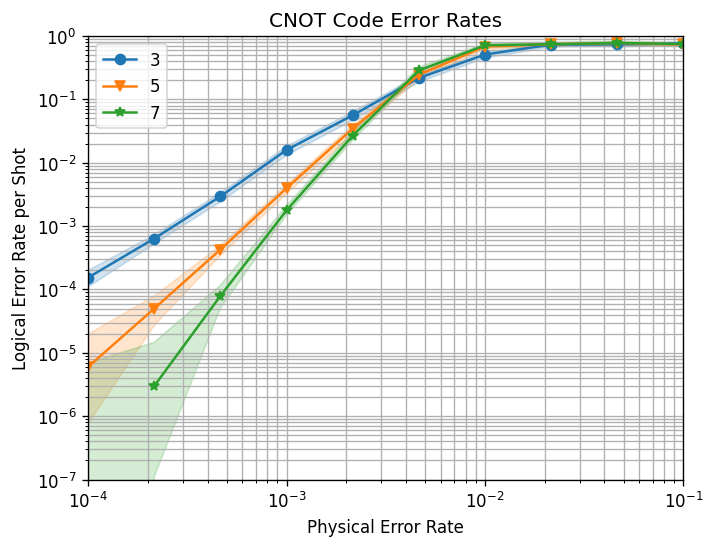

In [18]:
from typing import List
import sinter
from matplotlib import pyplot as plt
import numpy as np

tasks = [
    sinter.Task(
        circuit=cnot_rsc_circuit(distance=d, physical_noise=noise),
        json_metadata={"d": d, "p": noise},
    )
    for d in [3, 5, 7]
    for noise in list(np.logspace(-4, -1, 10))
]

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=1_000_000,
    max_errors=500,
)
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: stats.json_metadata["d"],
)
ax.set_ylim(1e-7, 1e-0)
ax.set_xlim(1e-4, 1e-1)
ax.loglog()
ax.set_title("CNOT Code Error Rates")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)